# Yelp Business Analytics with MongoDB

Loads a Yelp sample (businesses, reviews, tips, users) into MongoDB, then works through filters, aggregation pipelines, `$lookup` joins, and `2dsphere` geospatial queries around Santa Barbara, CA.

## Setup

In [3]:
# import statements
from pymongo import MongoClient
import bson
from datetime import datetime
import os

In [ ]:
!unzip yelp_ca_sample.zip

Archive:  yelp_ca_sample.zip
replace yelp_ca_sample/users.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
client = MongoClient('mongodb://localhost:27017/')
db = client["yelp_ca_sample"]

In [5]:
json_dir = "yelp_ca_sample"

json_files = [f for f in os.listdir(json_dir) if f.endswith(".json")]
print("JSON files:", json_files)

for fname in json_files:
    coll_name = fname.replace(".json", "")
    file_path = os.path.join(json_dir, fname)

    db[coll_name].delete_many({})

    count = 0
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            doc = bson.json_util.loads(line)
            db[coll_name].insert_one(doc)
            count += 1

    print(f"Loaded {count} docs into '{coll_name}'")

JSON files: ['users.json', 'reviews.json', 'tips.json', 'businesses.json']
Loaded 157445 docs into 'users'
Loaded 348856 docs into 'reviews'
Loaded 38102 docs into 'tips'
Loaded 5203 docs into 'businesses'


## Filters, projections, and counts

In [16]:
result = db.businesses.find_one({}, {"_id": 0})


result

{'business_id': 'Pns2l4eNsfO8kk83dixA6A',
 'name': 'Abby Rappoport, LAC, CMQ',
 'address': '1616 Chapala St, Ste 2',
 'city': 'Santa Barbara',
 'state': 'CA',
 'postal_code': '93101',
 'latitude': 34.4266787,
 'longitude': -119.7111968,
 'stars': 5.0,
 'review_count': 7,
 'is_open': 0,
 'attributes': {'ByAppointmentOnly': 'True'},
 'categories': 'Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists',
 'hours': None,
 'loc': {'type': 'Point', 'coordinates': [-119.7111968, 34.4266787]}}

In [17]:
cursor = db.businesses.find(
    {"city": "Santa Barbara"},
    {"_id": 0}
)
result = list(cursor)
    result

In [18]:
cursor = db.users.find({}, {"_id": 0}).limit(5)
result = list(cursor)


result

[{'user_id': 'qVc8ODYU5SZjKXVBgXdI7w',
  'name': 'Walker',
  'review_count': 585,
  'yelping_since': '2007-01-25 16:47:26',
  'useful': 7217,
  'funny': 1259,
  'cool': 5994,
  'elite': '2007',
  'friends': 'NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA, EjlCGf14tYMPJ0rsrL703w, 7OagHIAKx2Rm9z3CQ0OmvA, uZoFvKs0dahfffIqHQf1eA, TW7-U8Y_SYsAX91Ol5LlfA, 6EDA76lfkaTyOeuxkg0Fmw, MsTKApUX1VF2Mv9jpUIG5g, Rq4TAwX8vj0Ccc3Pt0mJ5g, P77zKKIP9xyakKLRutvdAQ, pOqaU6X1xyWUoYJJdoqbBw, 1aU0r7X2luo9P8hfSpq6ng, 7XDyuBY0mhLsaGqjquh8rw, KrnJZsROH6jsiCN_RHG_8Q, 48zQrAJNOqcKJJgqU5WzbQ, 48wN4GpyJ7hPy4uuwpGFmw, z8zzFMKCnavBY5_-_vzi9w, BemKKkZBBmu9GupEwKBj9g, vVS0rY7uZ2UZ6bdsDzSPIQ, hc6-o0VhNPw3qR3Pv7Knmg, 2AOUvDvG7rvAX1hLI5QZKA, dKzMVnYh_tvIQbDm6pTlRA, ACHQbmN7OMTY6PFz5Sl4_g, 8hqS8Wul46dt370JVRA83Q, TMLVzNYs-zwwREudyvI08A, 36LgEtwt6ROhrCtuPjfRmQ, -f6amuvfIVS7VX65BqZ6pQ, kCjFwGXHxUTaJ23p70j86w, d9J7e2uo-a0S0XMuw1CS-A, dbrGVOcscXUQjQGi_0bnaQ, a_luWCTl-TLAgvsgfn8dfw, -cnGMlaftdo8HGVrQwKE3Q, p2ww1kRTv0z9dT3gZYcDkg, 

In [19]:
result = db.businesses.find_one({"stars": 4.0}, {"_id": 0})


result

{'business_id': 'IDtLPgUrqorrpqSLdfMhZQ',
 'name': 'Helena Avenue Bakery',
 'address': '131 Anacapa St, Ste C',
 'city': 'Santa Barbara',
 'state': 'CA',
 'postal_code': '93101',
 'latitude': 34.4144445,
 'longitude': -119.6906718,
 'stars': 4.0,
 'review_count': 389,
 'is_open': 1,
 'attributes': {'RestaurantsTakeOut': 'True',
  'NoiseLevel': "u'average'",
  'Caters': 'True',
  'Ambience': "{'touristy': False, 'hipster': True, 'romantic': False, 'divey': False, 'intimate': False, 'trendy': True, 'upscale': False, 'classy': False, 'casual': True}",
  'RestaurantsReservations': 'False',
  'BusinessAcceptsCreditCards': 'True',
  'RestaurantsTableService': 'False',
  'GoodForKids': 'True',
  'RestaurantsPriceRange2': '2',
  'WheelchairAccessible': 'True',
  'OutdoorSeating': 'True',
  'RestaurantsDelivery': 'None',
  'HasTV': 'False',
  'RestaurantsAttire': "'casual'",
  'Alcohol': "u'none'",
  'GoodForMeal': "{'dessert': False, 'latenight': False, 'lunch': True, 'dinner': False, 'brunch'

In [20]:
result = db.businesses.count_documents({})
    result

In [21]:
result = db.businesses.count_documents({"review_count": {"$gt": 500}})

result

101

In [22]:
result = db.businesses.count_documents({"postal_code": "93101"})

    result

In [23]:
result = db.users.count_documents({"elite": {"$ne": ""}})

    result

In [24]:
cursor = db.businesses.find(
    {"city": "Santa Barbara", "stars": 5.0},
    {"_id": 0, "name": 1}
).sort("name", 1)

result = list(cursor)

    result

In [25]:
cursor = db.reviews.find({}, {"_id": 0}).sort("cool", -1).limit(5)
result = list(cursor)

result

[{'review_id': '32bYcL4TdFpYS_KVD163yg',
  'user_id': '95GOfKoCDfeGkX2l8n8Lfw',
  'business_id': 'DEmAmcR4xNilT5WY5ImEFA',
  'stars': 5.0,
  'useful': 181,
  'funny': 112,
  'cool': 184,
  'text': 'Pssst...over here...Let\'s GO discover the especial!\n\nI stumbled upon this wonderful place while in Santa Barbara and I\'m so happy I did. They have every dish of Mexican food you can think of nachos, burritos, tacos, and more--conscious Mexican food that is. Let\'s discover one of the many especials. The restaurant space is small but the food quality makes up for it as it\'s delicious and nutritious.\n\nI ordered the tacos which comes with three total. To begin, one must choose a carb, meatless protein, and fixings. I ordered the barbacoa (gluten free) which is the jackfruit and they are quite generous on the guacamole servings I had added--see photo. I took a bite and it was amazing! (Ohh, I have a little guac on my mouth lol seriousLY.) The salsa was a very nice touch. Everything was so

In [31]:
result = db.businesses.count_documents({"categories": {"$regex": "Pizza"}})
result

113

In [32]:
cursor = db.businesses.find(
    {"stars": {"$gte": 3.5, "$lte": 4.5}},
    {"_id": 0, "name": 1, "stars": 1, "city": 1}
)
result = list(cursor)

result

[{'name': 'Helena Avenue Bakery', 'city': 'Santa Barbara', 'stars': 4.0},
 {'name': 'Iron Horse Auto Body', 'city': 'Santa Barbara', 'stars': 4.5},
 {'name': 'Santa Barbara Shellfish Company',
  'city': 'Santa Barbara',
  'stars': 4.0},
 {'name': '805 Ink', 'city': 'Santa Barbara', 'stars': 4.5},
 {'name': 'Enjoy The Mountain', 'city': 'Santa Barbara', 'stars': 4.5},
 {'name': 'California Tacos and Taproom', 'city': 'Isla Vista', 'stars': 4.0},
 {'name': "Marty's Pizza", 'city': 'Santa Barbara', 'stars': 4.0},
 {'name': 'Cal Taco', 'city': 'Goleta', 'stars': 4.0},
 {'name': 'Prop and Decor Outlet: The Tent Merchant Inc.',
  'city': 'Santa Barbara',
  'stars': 4.0},
 {'name': 'Tienda Ho', 'city': 'Santa Barbara', 'stars': 4.5},
 {'name': 'Challenge Asphalt Paving', 'city': 'Santa Barbara', 'stars': 4.0},
 {'name': 'Dune Coffee Roasters - Anacapa',
  'city': 'Santa Barbara',
  'stars': 4.0},
 {'name': 'Siam Elephant', 'city': 'Carpinteria', 'stars': 4.5},
 {'name': 'Franceschi Park', 'ci

In [33]:
result = db.businesses.count_documents({"attributes.WheelchairAccessible": "True"})


result

995

In [74]:
cursor = db.reviews.find({"date": {"$regex": "^2018"}},{"_id": 0})
result = list(cursor)


result[:5]

[{'review_id': 'b1GkT5ojVlMCM6jdwPi3wQ',
  'user_id': 'JcUxoKPqBBRaMcHaQOYFlg',
  'business_id': '_v3DcLatG70adfYzWTd-CQ',
  'stars': 5.0,
  'useful': 0,
  'funny': 0,
  'cool': 0,
  'text': 'Best smoothies in the whole world. And fresh bread is amazing. Very knowledgeable staff.',
  'date': '2018-04-04 00:31:57'},
 {'review_id': 's_X5uNLjLSgK_itDNFiadg',
  'user_id': 'NZdASLiCRqQI1yIl9MIY5w',
  'business_id': 'MbzgGsMQpGyVrUJXi_Jw0Q',
  'stars': 4.0,
  'useful': 0,
  'funny': 0,
  'cool': 0,
  'text': "I am from Colorado and am visiting Santa Barbara and let me tell you... what a great place to eat. The food was quality, but the customer service was even better. Also, I thought the price was really good for the amount of food you get. Food came out fast as well. Overall, I'd say it's a great breakfast place if you are in Santa Barbara",
  'date': '2018-03-15 19:16:02'},
 {'review_id': 'Q3fPo_x6xKxafAzy1hFITg',
  'user_id': 'ha2Lv7WnxvdYnRsqwL1apQ',
  'business_id': 'IDtLPgUrqorrpqSLdf

In [46]:
cities = db.businesses.distinct(
    "city",
    {"categories": {"$regex": r"\bIndian\b"}}
)
result = sorted([c for c in cities if c is not None])

result[:10]

['Goleta', 'Isla Vista', 'Santa Barbara']

In [64]:
cursor = db.reviews.find({"date": {"$gte": "2021-01-01"}},
    {"_id": 0})
result = list(cursor)


result[:3]

[{'review_id': 'milJ7UH4Od9pBe2gWac9tA',
  'user_id': 'v7i4M7NIx3bMNMChaXjU7Q',
  'business_id': 'raKflkp3CANr8N7qpQ3ZyQ',
  'stars': 5.0,
  'useful': 0,
  'funny': 0,
  'cool': 0,
  'text': "I WISH I was still a Sierra resident. They're definitely one of the best property management companies in Isla Vista (and that's saying something). They're super easy to work with and they are GREAT in comparison to other landlords in IV that will try to take every last dime you have to give.",
  'date': '2021-02-02 18:14:15'},
 {'review_id': 'SsRO-i17eK_-QaZDWakdSg',
  'user_id': '0Hl_MXpE6FeahlVn68aq4w',
  'business_id': 'iHdrLu8deF5GceB0V1rPhA',
  'stars': 4.0,
  'useful': 0,
  'funny': 0,
  'cool': 0,
  'text': "I would give Oliver's 4.5 stars if that was an option. Amazing outdoor set up. The apple salad and the chopped salad were our two favorite items. We also really liked the japanese yams.",
  'date': '2021-03-31 05:17:50'},
 {'review_id': 'Q_Cyw28LTpvO9ojmBlKYXA',
  'user_id': 'RGvob4AFB

In [48]:
result = db.reviews.count_documents({"business_id": "na2fvJ5LN7ZcUJcM4kkjJg"})

result

57

In [49]:
cursor = db.businesses.find(
    {"stars": {"$gte": 4.5}},
    {"_id": 0, "name": 1, "review_count": 1, "city": 1}
).sort("review_count", -1).limit(10)
result = list(cursor)


result

[{'name': 'Los Agaves', 'city': 'Santa Barbara', 'review_count': 3834},
 {'name': 'Mesa Verde', 'city': 'Santa Barbara', 'review_count': 1796},
 {'name': "McConnell's Fine Ice Creams",
  'city': 'Santa Barbara',
  'review_count': 1537},
 {'name': 'The Palace Grill', 'city': 'Santa Barbara', 'review_count': 1500},
 {'name': 'Lure Fish House', 'city': 'Santa Barbara', 'review_count': 1453},
 {'name': 'Bouchon', 'city': 'Santa Barbara', 'review_count': 1452},
 {'name': 'Rockfire Grill', 'city': 'Goleta', 'review_count': 1246},
 {'name': "Lilly's Tacos", 'city': 'Santa Barbara', 'review_count': 1219},
 {'name': 'Pickles & Swiss', 'city': 'Santa Barbara', 'review_count': 1213},
 {'name': 'The Shop Kitchen', 'city': 'Santa Barbara', 'review_count': 1108}]

## Aggregation pipelines (`$group`, `$unwind`, `$lookup`)

In [50]:
pipeline = [
    {"$match": {"city": "Santa Barbara"}},
    {"$group": {"_id": None, "avg_stars": {"$avg": "$stars"}}}
]

res = list(db.businesses.aggregate(pipeline))
avg = res[0]["avg_stars"] if res else 0.0
result = round(avg, 2)


result

4.05

In [54]:
pipeline = [
    {"$group": {"_id": "$user_id", "total_tips": {"$sum": 1}}},
    {"$sort": {"total_tips": -1}},
    {"$limit": 5},
    {"$project": {"_id": 0, "user_id": "$_id", "total_tips": 1}}
]

result = list(db.tips.aggregate(pipeline))


result

[{'total_tips': 412, 'user_id': '4DyMRBKrokax6d8LCI3GAw'},
 {'total_tips': 335, 'user_id': 'A4bsa7ykYRVCnb4h2vZALw'},
 {'total_tips': 236, 'user_id': '7Na1pUcEv3oF_QTRwZ-2iw'},
 {'total_tips': 190, 'user_id': 'DGZTz4K3czUM0OoKGK2pDg'},
 {'total_tips': 159, 'user_id': 'iEVNgH8leU1xtkFWlEfH-g'}]

In [55]:
res_21 = list(db.tips.aggregate([
    {"$group": {"_id": "$user_id", "total_tips": {"$sum": 1}}},
    {"$match": {"total_tips": {"$gte": 50}}},
    {"$count": "user_count"}
]))
result = res_21[0]['user_count'] if res_21 else 0

result

46

In [56]:
pipeline = [
    {"$match": {"categories": {"$regex": r"\bLimos\b"}}},
    {"$group": {"_id": None, "avg_stars": {"$avg": "$stars"}}}
]

res = list(db.businesses.aggregate(pipeline))
avg = res[0]["avg_stars"] if res else 0.0
result = round(avg, 2)


result

4.46

In [57]:
pipeline = [
    {"$match": {"categories": {"$ne": None}}},
    {"$addFields": {"category_list": {"$split": ["$categories", ", "]}}},
    {"$unwind": "$category_list"},
    {"$group": {"_id": "$category_list", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
    {"$limit": 3},
    {"$project": {"_id": 1, "count": 1}}]
result = list(db.businesses.aggregate(pipeline))


result

[{'_id': 'Restaurants', 'count': 1161},
 {'_id': 'Shopping', 'count': 936},
 {'_id': 'Food', 'count': 835}]

In [58]:
pipeline = [
    {"$match": {"categories": {"$ne": None}}},
    {"$addFields": {"category_list": {"$split": ["$categories", ", "]}}},
    {"$unwind": "$category_list"},
    {"$group": {"_id": "$category_list", "avg_stars": {"$avg": "$stars"}}},
    {"$project": {"_id": 1, "average_rating": {"$round": ["$avg_stars", 2]}}},
    {"$sort": {"average_rating": 1, "_id": 1}},
    {"$limit": 5}
]
result = list(db.businesses.aggregate(pipeline))


result

[{'_id': 'Television Service Providers', 'average_rating': 1.25},
 {'_id': 'Debt Relief Services', 'average_rating': 1.5},
 {'_id': 'Software Development', 'average_rating': 1.5},
 {'_id': 'Internet Service Providers', 'average_rating': 1.7},
 {'_id': 'Behavior Analysts', 'average_rating': 2.0}]

In [60]:
pipeline = [
    {"$match": {"city": "Isla Vista"}},
    {"$lookup": {
        "from": "reviews",
        "localField": "business_id",
        "foreignField": "business_id",
        "as": "rev"
    }},
    {"$unwind": "$rev"},
    {"$group": {
        "_id": "$name",
        "positive_reviews": {
            "$sum": {"$cond": [{"$in": ["$rev.stars", [4, 5]]}, 1, 0]}
        },
        "negative_reviews": {
            "$sum": {"$cond": [{"$in": ["$rev.stars", [1, 2]]}, 1, 0]}
        }
    }},
    {"$sort": {"positive_reviews": -1}},
    {"$limit": 5}
]
result = list(db.businesses.aggregate(pipeline))

result

[{'_id': 'Freebirds', 'positive_reviews': 999, 'negative_reviews': 125},
 {'_id': "Woodstock's Pizza Isla Vista",
  'positive_reviews': 371,
  'negative_reviews': 70},
 {'_id': 'Dank Bowl Kitchen', 'positive_reviews': 285, 'negative_reviews': 26},
 {'_id': 'Cajé Coffee Roasters - Isla Vista',
  'positive_reviews': 229,
  'negative_reviews': 18},
 {'_id': 'Naan Stop', 'positive_reviews': 197, 'negative_reviews': 81}]

In [62]:
pipeline = [
    {"$group": {"_id": "$user_id", "biz_set": {"$addToSet": "$business_id"}}},
    {"$project": {"_id": 1, "unique_businesses": {"$size": "$biz_set"}}},
    {"$sort": {"unique_businesses": -1}},
    {"$limit": 1}
]
result = list(db.reviews.aggregate(pipeline))

result

[{'_id': 'ZDCWEctaQHfJQT1sH_rMmA', 'unique_businesses': 472}]

In [63]:
pipeline = [
    {"$group": {"_id": "$user_id", "review_count": {"$sum": 1}}},
    {"$sort": {"review_count": -1}},
    {"$limit": 5}
]

result = list(db.reviews.aggregate(pipeline))


result

[{'_id': 'ZDCWEctaQHfJQT1sH_rMmA', 'review_count': 476},
 {'_id': '7Na1pUcEv3oF_QTRwZ-2iw', 'review_count': 351},
 {'_id': '-B-QEUESGWHPE_889WJaeg', 'review_count': 339},
 {'_id': 'o6UJMpHcpLJEvmKLrxLS3w', 'review_count': 317},
 {'_id': 'qunxFdBDVl0ordRJEPVNtQ', 'review_count': 305}]

## Geospatial queries (`2dsphere`, `$geoWithin`, `$near`)

In [70]:
db.businesses.create_index([("loc", "2dsphere")])

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Function to plot businesses on a map
def plot_businesses(cursor_result, filename):
    """
    cursor_result: List of dictionaries (documents) returned by pymongo
    filename: output image name (without extension)
    """
    
    businesses = list(cursor_result)
    
    if not businesses:
        print(f"Query returned no results for {filename}. Plot will be empty.")
        return

    longitudes = [b['loc']['coordinates'][0] for b in businesses]
    latitudes = [b['loc']['coordinates'][1] for b in businesses]

    gdf = gpd.GeoDataFrame(
        businesses, 
        geometry=gpd.points_from_xy(longitudes, latitudes)
    )

    # Load Background Map (Santa Barbara Limits)
    # Ensure this file is present in your directory
    world = gpd.read_file("santa_barbara_limits.geojson")
    
    if gdf.crs is None:
        gdf = gdf.set_crs(world.crs)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the city limits as the background
    world.plot(ax=ax, color='whitesmoke', edgecolor='black', alpha=0.5)
    
    # Plot the businesses
    gdf.plot(ax=ax, marker='o', color='red', markersize=15, alpha=0.7, label='Businesses')

    plt.title(f"Business Locations ({filename})")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    
    plt.savefig(f'{filename}.png')
    plt.show()

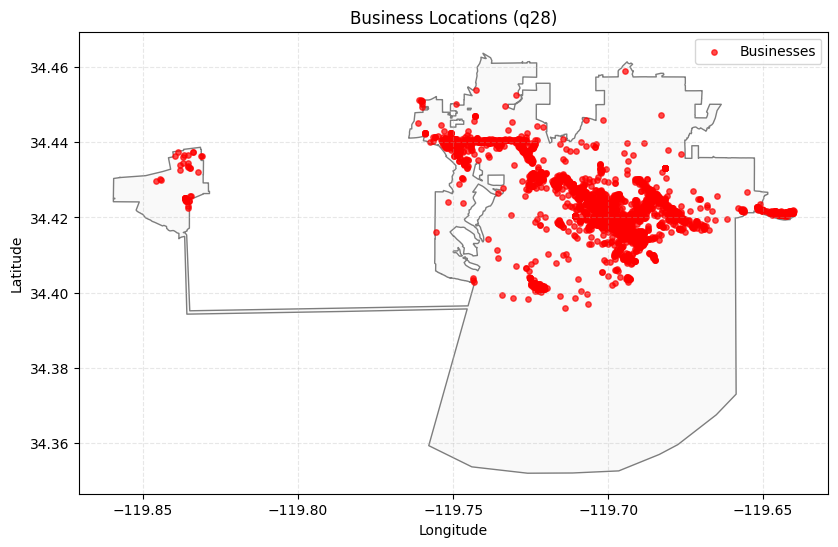

In [67]:
#28
import json
import geopandas as gpd

sb = gpd.read_file("santa_barbara_limits.geojson")
polygon = sb.geometry.iloc[0]
geojson_geom = json.loads(gpd.GeoSeries([polygon]).to_json())["features"][0]["geometry"]

cursor = db.businesses.find({
    "loc": {"$geoWithin": {"$geometry": geojson_geom}}
})

plot_businesses(cursor, "map_santa_barbara")

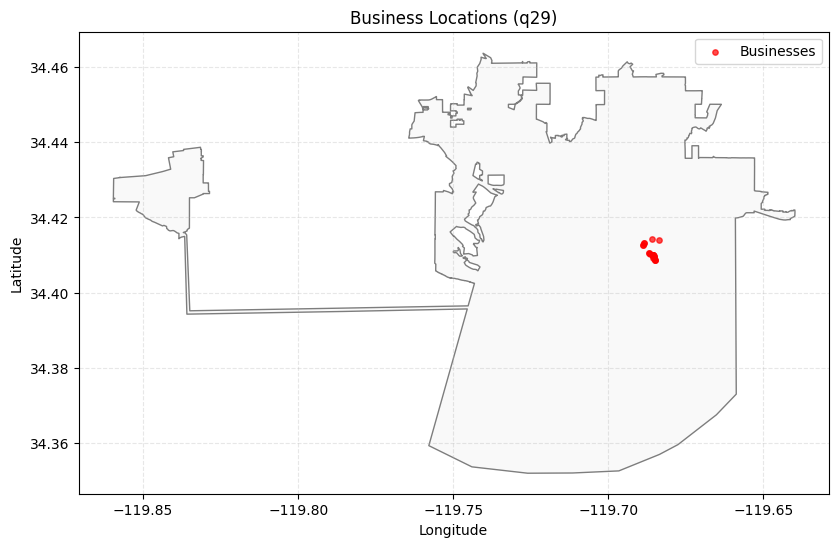

In [71]:
wharf_point = {"type": "Point", "coordinates": [-119.6846, 34.4099]}

cursor29 = db.businesses.find({
    "loc": {"$near": {"$geometry": wharf_point}}
}).limit(25)
plot_businesses(cursor29, "map_stearns_wharf")

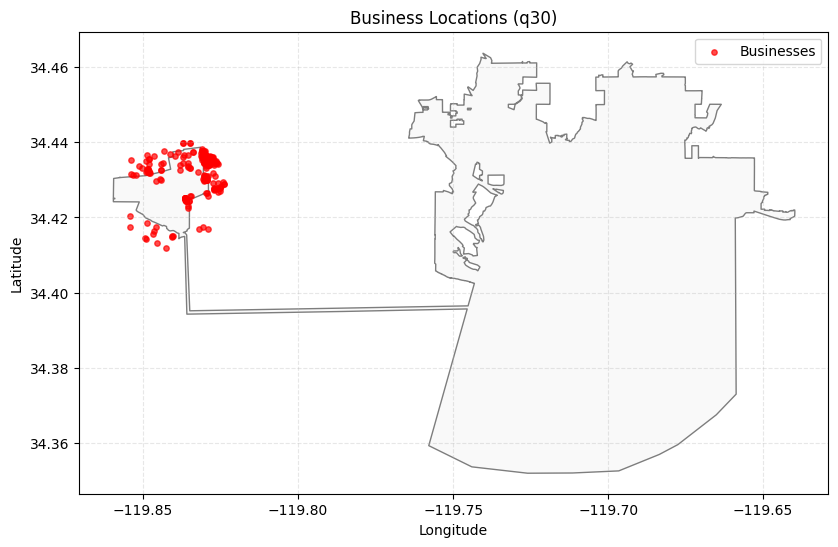

In [72]:
EARTH_RADIUS_MILES = 3963.2
radius_radians = 1 / EARTH_RADIUS_MILES
airport_coords = [-119.8404, 34.4262]

cursor30 = db.businesses.find({
    "loc": {
        "$geoWithin": {
            "$centerSphere": [airport_coords, radius_radians]
        }
    }
})
plot_businesses(cursor30, "map_sb_airport")